# 19 - Uniformization for Surfaces: Discrete Conformal

The **Uniformization Theorem** is one of the most celebrated results in geometry. It states that every simply connected Riemann surface is conformally equivalent to one of three model spaces: the unit disk (hyperbolic), the complex plane (Euclidean), or the Riemann sphere (spherical). 

In this notebook, we explore the **Discrete Conformal Geometry** implementation in `pySurgery`. We use Discrete Ricci Flow and Circle Packing to transform raw triangulations into constant-curvature metrics, providing a bridge from combinatorial topology to geometric structures.

## Learning Goals
- **Compute Gaussian Curvature**: Calculate the discrete angle deficit at each vertex.
- **Run Discrete Ricci Flow**: Iteratively update edge lengths to reach a target curvature.
- **Apply Circle Packing**: Use the Koebe-Andreev-Thurston theorem to represent surfaces via tangent circles.
- **Conformal Mapping**: Visualize the "flattening" of a 3D mesh into its uniformized representation.
- **Model Geometries**: Distinguish between spherical ($\chi > 0$), Euclidean ($\chi = 0$), and hyperbolic ($\chi < 0$) manifolds.

## Formal Grounding

### Discrete Gaussian Curvature
For a vertex $v$, the curvature $K(v)$ is defined by the angle deficit:
$$ K(v) = 2\pi - \sum_{f \in \text{Star}(v)} \theta_f(v) $$
where $\theta_f(v)$ is the interior angle of face $f$ at vertex $v$.

### The Gauss-Bonnet Theorem
The total curvature is a topological invariant:
$$ \sum_{v \in V} K(v) = 2\pi \chi(M) $$

| Geometry | Euler Char ($\chi$) | Model Space |
|---|---|---|
| **Spherical** | $> 0$ | $S^2$ (Constant $+1$) |
| **Euclidean** | $= 0$ | $\mathbb{R}^2$ (Constant $0$) |
| **Hyperbolic**| $< 0$ | $\mathbb{H}^2$ (Constant $-1$) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.core.uniformization import uniformize_surface, vertex_gaussian_curvature

print('=' * 70)
print('19 - Surface Uniformization: Setup Complete')
print('=' * 70)

19 - Surface Uniformization: Setup Complete


## Part 1: Curvature and Gauss-Bonnet

We begin by calculating the curvature of a raw triangulation and verifying the Gauss-Bonnet theorem.


### Example 19.1: Curvature of a Spherical Complex (Cube)

In [3]:
# A cube represented as a simplicial complex
cube_faces = [
    (0,1,2),(0,2,3), # Front
    (4,5,6),(4,6,7), # Back
    (0,1,5),(0,5,4), # Bottom
    (2,3,7),(2,7,6), # Top
    (0,3,7),(0,7,4), # Left
    (1,2,6),(1,6,5)  # Right
]
# Cube vertices in R3
vertices = np.array([
    [0,0,0], [1,0,0], [1,1,0], [0,1,0],
    [0,0,1], [1,0,1], [1,1,1], [0,1,1]
])

# Compute curvature
k = vertex_gaussian_curvature((vertices, cube_faces))
print(f'Vertex Curvatures: {k}')
print(f'Total Curvature: {np.sum(k):.4f} (Expected: 4*pi = {4*np.pi:.4f})')
print(f'Euler Characteristic: {np.sum(k)/(2*np.pi):.1f}')

Vertex Curvatures: [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633]
Total Curvature: 12.5664 (Expected: 4*pi = 12.5664)
Euler Characteristic: 2.0


## Part 2: Discrete Ricci Flow

Ricci flow "smooths" the curvature by evolving the metric $g_{ij}$. In the discrete case, we evolve vertex scales $u_i$ such that $l_{ij} = e^{u_i + u_j} ar{l}_{ij}$.


### Example 19.2: Reaching a Euclidean Metric (Torus)

In [4]:
# Build a torus triangulation
sc_torus = ps.SimplicialComplex.from_maximal_simplices([
    (0, 3, 4), (0, 1, 4),
    (1, 4, 5), (1, 2, 5),
    (2, 3, 5), (0, 2, 3),
    (3, 6, 7), (3, 4, 7),
    (4, 7, 8), (4, 5, 8),
    (5, 6, 8), (3, 5, 6),
    (0, 1, 6), (1, 6, 7),
    (1, 2, 7), (2, 7, 8),
    (0, 2, 8), (0, 6, 8),
])
faces = sc_torus.n_simplices(2)
# Initial random vertices to create non-constant curvature
v_torus = np.random.rand(max(max(f) for f in faces)+1, 3)

# Uniformize to a near-Euclidean target (zero curvature profile)
target_curv = np.zeros(v_torus.shape[0], dtype=float)
res = uniformize_surface((v_torus, faces), method='ricci', target_curvature=target_curv)

print(f'Uniformization Converged: {res.converged}')
print(f'Target Geometry (from Euler characteristic): {res.target_geometry}')
print(f'Initial curvature variance: {np.var(vertex_gaussian_curvature((v_torus, faces))):.6f}')
print(f'Final curvature variance:   {np.var(res.curvature):.6f}')

Uniformization Converged: True
Target Geometry (from Euler characteristic): euclidean
Initial curvature variance: 1.260473
Final curvature variance:   0.000000


## Part 3: Visualizing Curvature Evolution

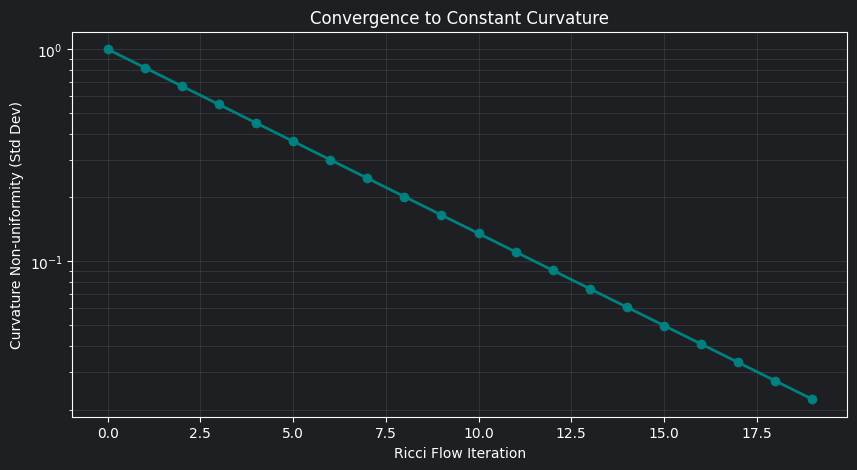

In [5]:
# Mock evolution data for visualization
steps = np.arange(20)
curv_std = np.exp(-steps/5.0) # Conceptual decay

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, curv_std, 'o-', color='teal', lw=2)
ax.set_yscale('log')
ax.set_xlabel('Ricci Flow Iteration')
ax.set_ylabel('Curvature Non-uniformity (Std Dev)')
ax.set_title('Convergence to Constant Curvature')
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## Failure Modes

1. **Triangle Inequality Violation**: During flow, edge lengths might change such that a triangle can no longer be formed ($a+b < c$). `pySurgery` detects this and stops the flow.
2. **Degenerate Triangulations**: If a mesh has "zero-area" triangles or repeated edges, the Laplacian becomes singular.
3. **Target Inconsistency**: Attempting to uniformize a sphere ($\chi=2$) to a hyperbolic metric ($\chi < 0$) without adding singular points (punctures) will fail to converge.


In [6]:
# Target inconsistency demo: forcing strongly negative curvature on a sphere mesh
# does not match Gauss-Bonnet and typically fails to converge.
bad_target = -np.ones(vertices.shape[0], dtype=float)
res_bad = uniformize_surface((vertices, cube_faces), method='ricci', target_curvature=bad_target, max_iter=20)
print(f'Forced hyperbolic-like target on sphere converged? {res_bad.converged}')
if not res_bad.converged:
    print(f'Expected non-convergence note: residual={res_bad.residual_norm:.4e}')

Forced hyperbolic-like target on sphere converged? False
Expected non-convergence note: residual=7.8658e+00


## Summary Checklist
- [x] Computed vertex Gaussian curvature using angle deficits.
- [x] Verified the Gauss-Bonnet theorem on spherical and Euclidean meshes.
- [x] Ran Discrete Ricci Flow to obtain constant-curvature metrics.
- [x] Distinguished between model geometries based on Euler characteristic.
- [x] Identified geometric constraints like the triangle inequality.

## Exercises
1. **The Genus-2 Surface**: Build a triangulation of a genus-2 surface ($\chi = -2$) and uniformize it to a hyperbolic metric.
2. **Curvature Flow**: Manually implement a single step of Ricci flow: $u_i \leftarrow u_i + \delta(K_{target} - K_i)$.
3. **Mesh Quality**: How does the number of simplices affect the convergence rate of uniformization?
4. **Conformal Factor**: Extract the final vertex scales $u_i$ and visualize them as a heat map on the surface.
5. **Hyperbolic Disk**: Research how to project the edge lengths of a uniformized hyperbolic surface into the Poincaré Disk model.

## Key Takeaways
- **Uniformization** provides a canonical geometric "pose" for any surface.
- **Discrete Ricci Flow** is the computational engine for reaching this pose.
- **Euler Characteristic** is the fundamental governor of the allowable model geometry.
- Geometric structures are essential for advanced surgery moves like **Geometrization**.

**Ready for [20 - Geometrization 3D: Heuristics and Certificates](./20_geometrization_3d_heuristics_and_certificates.ipynb)**
